In [1]:
origin = load_data('poisons')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/poisons.xlsx
[desc] 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)

field    description
-------  ------------------
time     동물의 생존시간
poison   사용된 독극물 종류
treat    사용되는 치료 유형


===== 데이터 크기 확인 =====
데이터셋 크기: (360, 3)
열 개수: 3
행 개수: 360

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    360 non-null    float64
 1   poison  360 non-null    object 
 2   treat   360 non-null    object 
dtypes: float64(1), object(2)
memory usage: 8.6+ KB
None


,time,poison,treat
0,3.8,P1,T1
1,2.7,P1,T1
2,1.7,P1,T1
3,2.2,P1,T1
4,0.7,P1,T1


1) 독 종류에 따른 치료유형별 생존시간

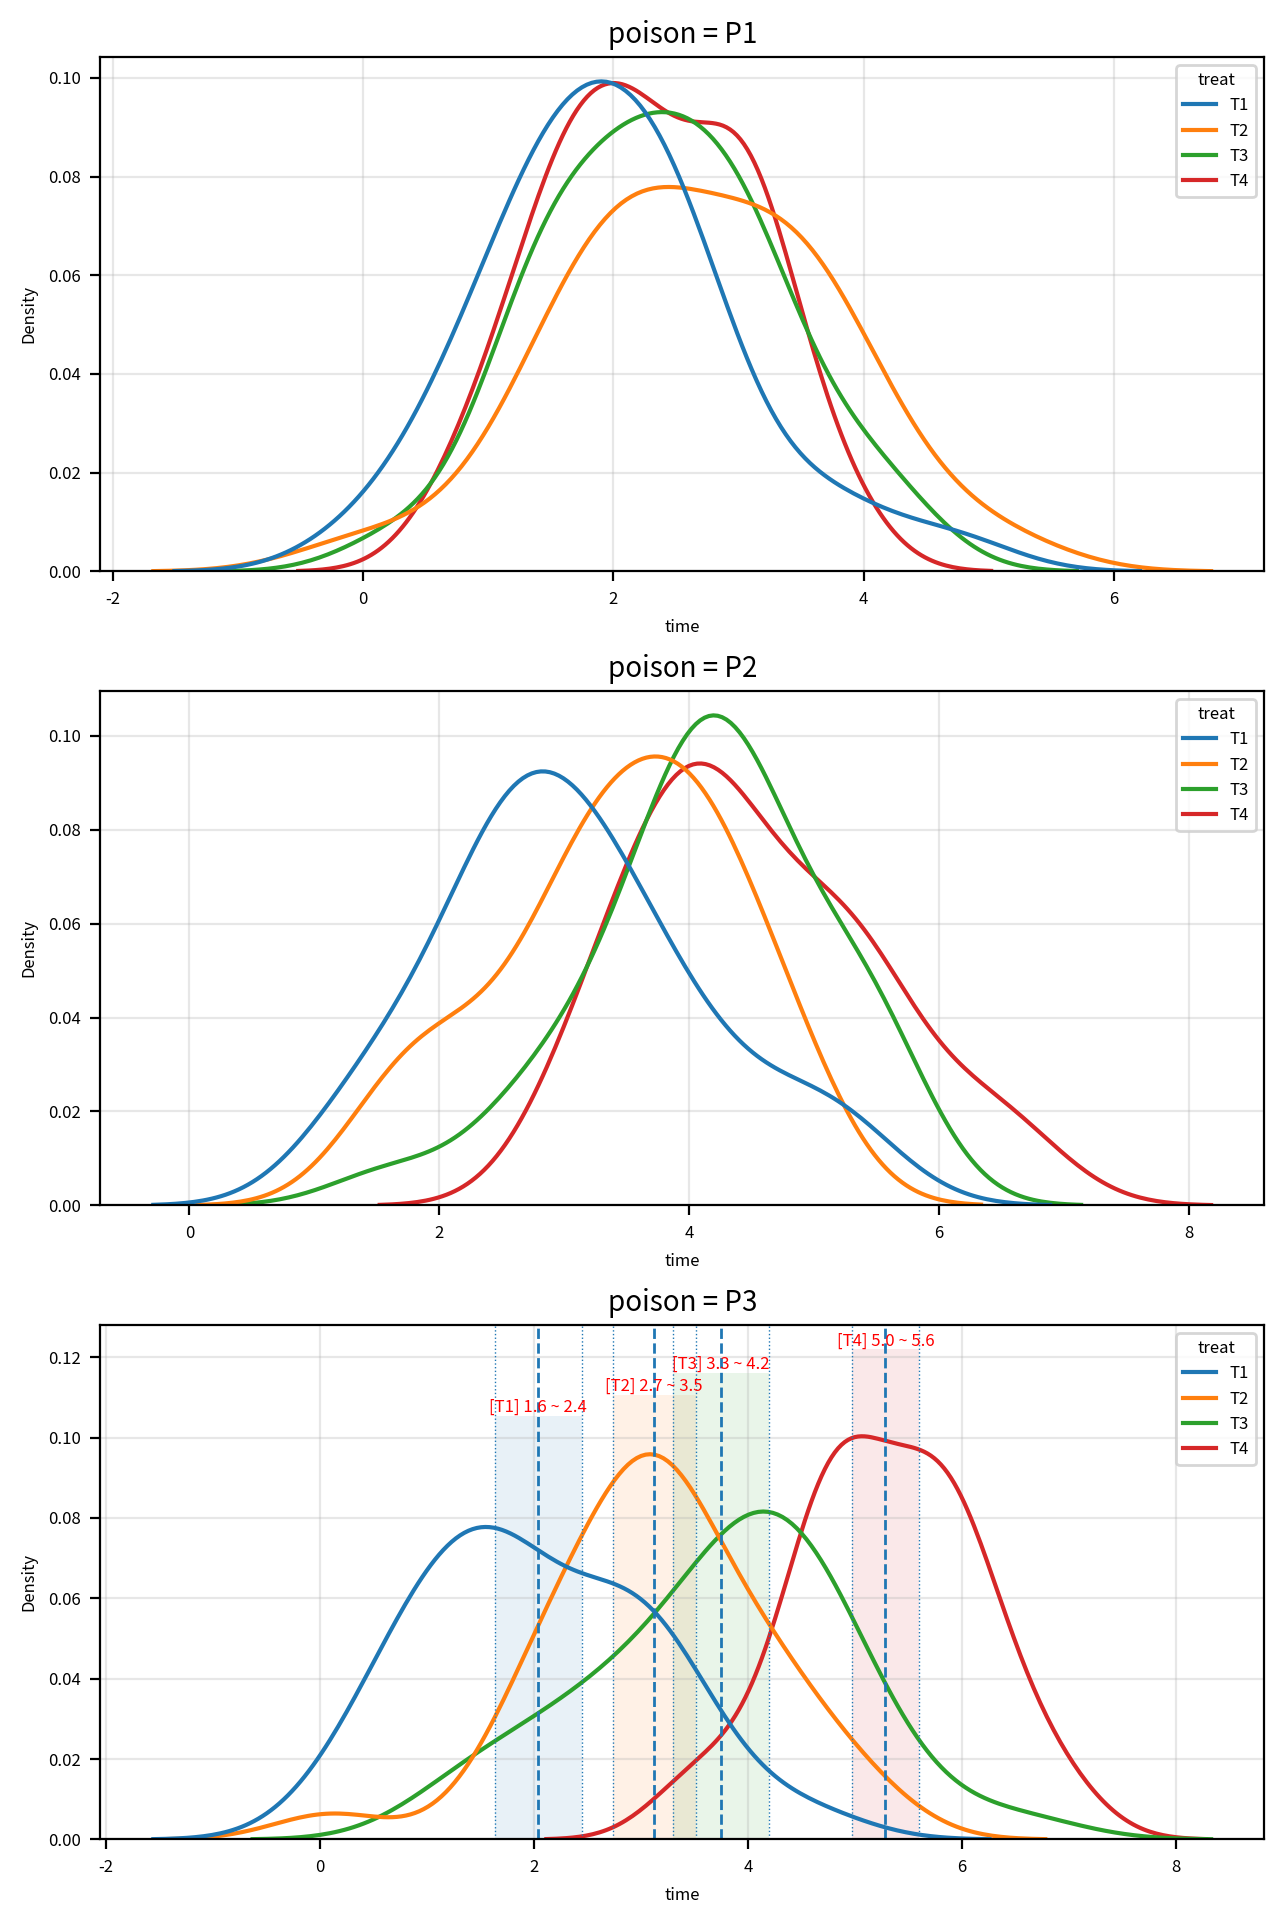

In [2]:
field = 'time'
group_field = 'poison'
hue_field = 'treat'
# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()
# 1) 그래프 초기화
rows = group_count # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 * cols # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) 그래프 그리기
for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title('{0} = {1}'.format(group_field, v), fontsize=10,
pad=5)
for h in hue_values:
    temp_sub = temp[temp[hue_field] == h]
    # 신뢰구간
    max = temp_sub[field].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(temp_sub[field]) - 1 # 자유도
    sp_mean = temp_sub[field].mean() # 표본평균
    sp_std = temp_sub[field].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp_sub[field])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
    scale=sp_std_error)
    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
    # 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

같은 독극물이라도 치료 방법에 따라 생존시간에 차이를 보이는 것 같지만, 명확한 판별은
어렵다.

2. 치료유형에 따른 독 종류별 생존시간

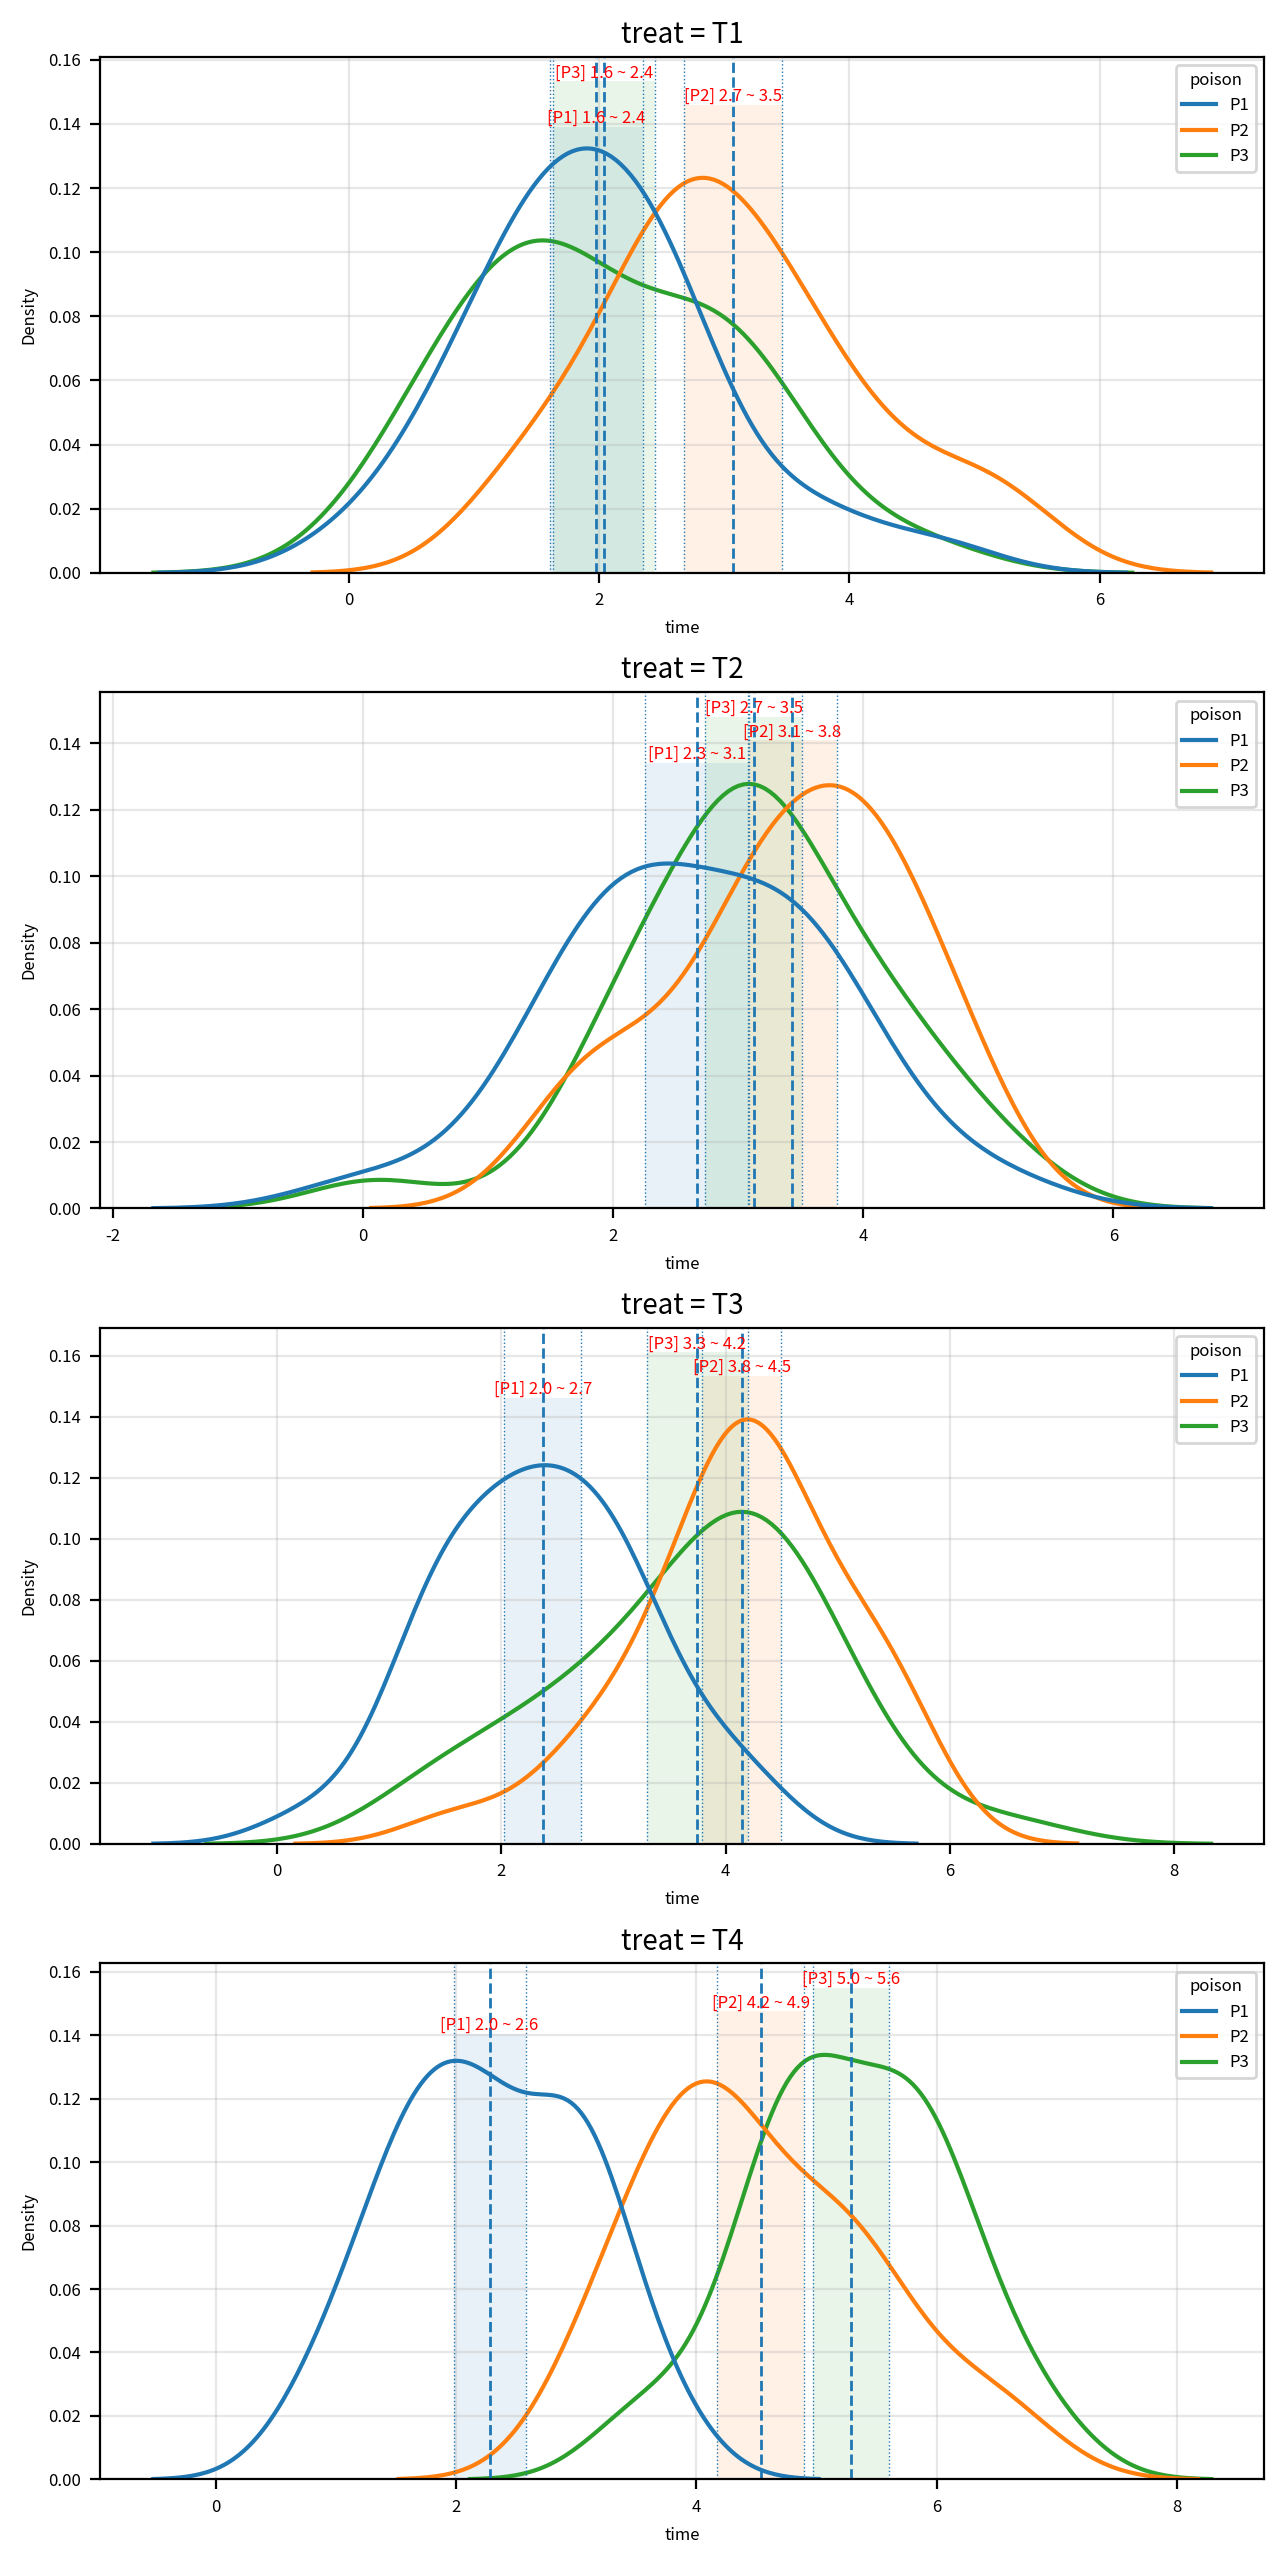

In [3]:
field = 'time'
group_field = 'treat'
hue_field = 'poison'
# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()
# 1) 그래프 초기화
rows = group_count # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 * cols # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) 그래프 그리기
for i, v in enumerate(group_values):        
    temp = data[data[group_field] == v]
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title('{0} = {1}'.format(group_field, v), fontsize=10,
        pad=5)
    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]
        # 신뢰구간
        max = temp_sub  [field].max() # 최대값
        clevel = 0.95 # 신뢰수준
        dof = len(temp_sub[field]) - 1 # 자유도
        sp_mean = temp_sub[field].mean() # 표본평균
        sp_std = temp_sub[field].std(ddof=1) # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field])) # 표본표준오차
        cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
        # 평균 표시
        ymin, ymax = ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
# 텍스트 그리기
        ax[i].text(x=(cmax-cmin)/2+cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

T1, T2, T3에서는 P2에 대한 생존시간이 가장 길었지만, T4에서는 P3에 대한 생존시간
이 긴것으로 보인다.

📝 3. 가정확인

In [4]:
data = origin.copy()
xname = ['treat', 'poison']
yname = 'time'
u1 = data[xname[0]].unique()
u2 = data[xname[1]].unique()
equal_var_fields = []
normal_dist = True
report = []
for i in u1:
    for j in u2:
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]]== j)][yname]
        equal_var_fields.append(filtered_data)
        s, p = normaltest(filtered_data)
        normalize = p > 0.05
        report.append({
            "field": "{0}, {1}".format(i, j),
            "statistic": s,
            "p-value": p,
            "result": normalize
        })
normal_dist = normal_dist and normalize
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)
equal_var = p > 0.05
report.append({
    "field": n,
    "statistic": s,
    "p-value": p,
    "result": p > 0.05
})
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
"T1, P1",3.660816,0.160348,True
"T1, P2",1.112279,0.573418,True
"T1, P3",0.837473,0.657878,True
"T2, P1",0.266462,0.875263,True
"T2, P2",1.509951,0.470022,True
"T2, P3",3.667273,0.159831,True
"T3, P1",0.014374,0.992839,True
"T3, P2",2.802084,0.246340,True
"T3, P3",0.424600,0.808722,True


📝 4. 분산분석 수행

In [5]:
xname = ['treat', 'poison']
yname = 'time'
data = origin[xname + [yname]]
if equal_var:
    pg_anova = anova(data=data, dv=yname, between=xname)
else:
    pg_anova = welch_anova(data=data, dv=yname, between=xname)
display(pg_anova)
for idx in pg_anova.index:
    row = pg_anova.iloc[idx]
    source = row['Source']
    p_val = row['p-unc']
    if p_val <= 0.05:
        print(f"→ {source} 효과는 유의함. (대립가설 채택: p ≤ 0.05)")
    else:
        print(f"→ {source} 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)")

,Source,SS,DF,MS,F,p-unc,np2
0,treat,131.260972,3,43.753657,43.891090,4.430485e-24,0.274506
1,poison,148.976389,2,74.488194,74.722166,1.002877e-27,0.300424
2,treat * poison,81.381611,6,13.563602,13.606206,6.938981e-14,0.190014
3,Residual,346.910333,348,0.996869,NaN,NaN,NaN


→ treat 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ poison 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ treat * poison 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ Residual 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)


📝 5. 사후검정

In [6]:
xname = ['treat', 'poison']
yname = 'time'
data = origin[xname + [yname]]

# 분산분석 결과표의 행 단위 반복
for index, row in pg_anova.iterrows():  # 행을 하나씩 꺼냄
    source_name = row['Source']         # 요인 이름 (treat, poison, treat * poison, Residual)
    p_value = row['p-unc']              # 각 요인의 p-value

    # 오차 및 상호작용은 제외
    if source_name == "Residual" or "*" in source_name:
        continue

    print(f"\n==== {source_name} ====")

    # 일반 요인인 경우
    if "*" not in source_name:
        level_count = data[source_name].nunique()  # 요인의 수준 수 계산

        if level_count <= 2:
            print(f"{level_count} 수준 요인이므로 사후검정이 필요 없습니다.")
            continue

    # 통계적으로 유의하지 않은 경우 사후검정 생략
    if p_value > 0.05:
        print(f"{source_name} 효과 유의하지 않음 (p={p_value:.3g}) → 사후검정 수행 안 함")
        continue

    # 사후검정 수행
    if equal_var:
        print("Tukey HSD 사용 (등분산 충족)")
        hoc_df = pairwise_tukey(data=data, dv=yname, between=source_name)
    else:
        print("Games–Howell 사용 (등분산 불충족)")
        hoc_df = pairwise_gameshowell(data=data, dv=yname, between=source_name)

    display(hoc_df)



==== treat ====
Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,T1,T2,2.363333,3.075556,-0.712222,0.189827,-3.751957,1.168920e-03,-0.639750
1,T1,T3,2.363333,3.421111,-1.057778,0.189827,-5.572330,2.971230e-07,-0.867932
2,T1,T4,2.363333,4.034444,-1.671111,0.189827,-8.803345,6.006307e-14,-1.220199
3,T2,T3,3.075556,3.421111,-0.345556,0.189827,-1.820373,2.654092e-01,-0.292572
4,T2,T4,3.075556,4.034444,-0.958889,0.189827,-5.051387,4.181336e-06,-0.717648
5,T3,T4,3.421111,4.034444,-0.613333,0.189827,-3.231015,7.343056e-03,-0.430346



==== poison ====
Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,P1,P2,2.325000,3.795833,-1.470833,0.161626,-9.100235,5.107026e-14,-1.388884
1,P1,P3,2.325000,3.550000,-1.225000,0.161626,-7.579233,9.585666e-13,-0.931693
2,P2,P3,3.795833,3.550000,0.245833,0.161626,1.521002,2.822579e-01,0.179210


📝 6 인사이트

📘 문제 2<br>
tomato 데이터 셋은 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에<br>
어떤 영향을 주는지에 대한 실험 결과이다.<br>
분산분석을 하여 효소 함량에 따라 토마토 모종 성장에 차이가 나는지 검정하라.<br>

In [7]:
origin = load_data('tomato')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/tomato.xlsx
[desc] 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (90, 2)
열 개수: 2
행 개수: 90

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   효소함량    90 non-null     int64  
 1   모종성장    90 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.5 KB
None


,효소함량,모종성장
0,0,9.5
1,0,10.0
2,0,10.7
3,0,9.0
4,0,12.4


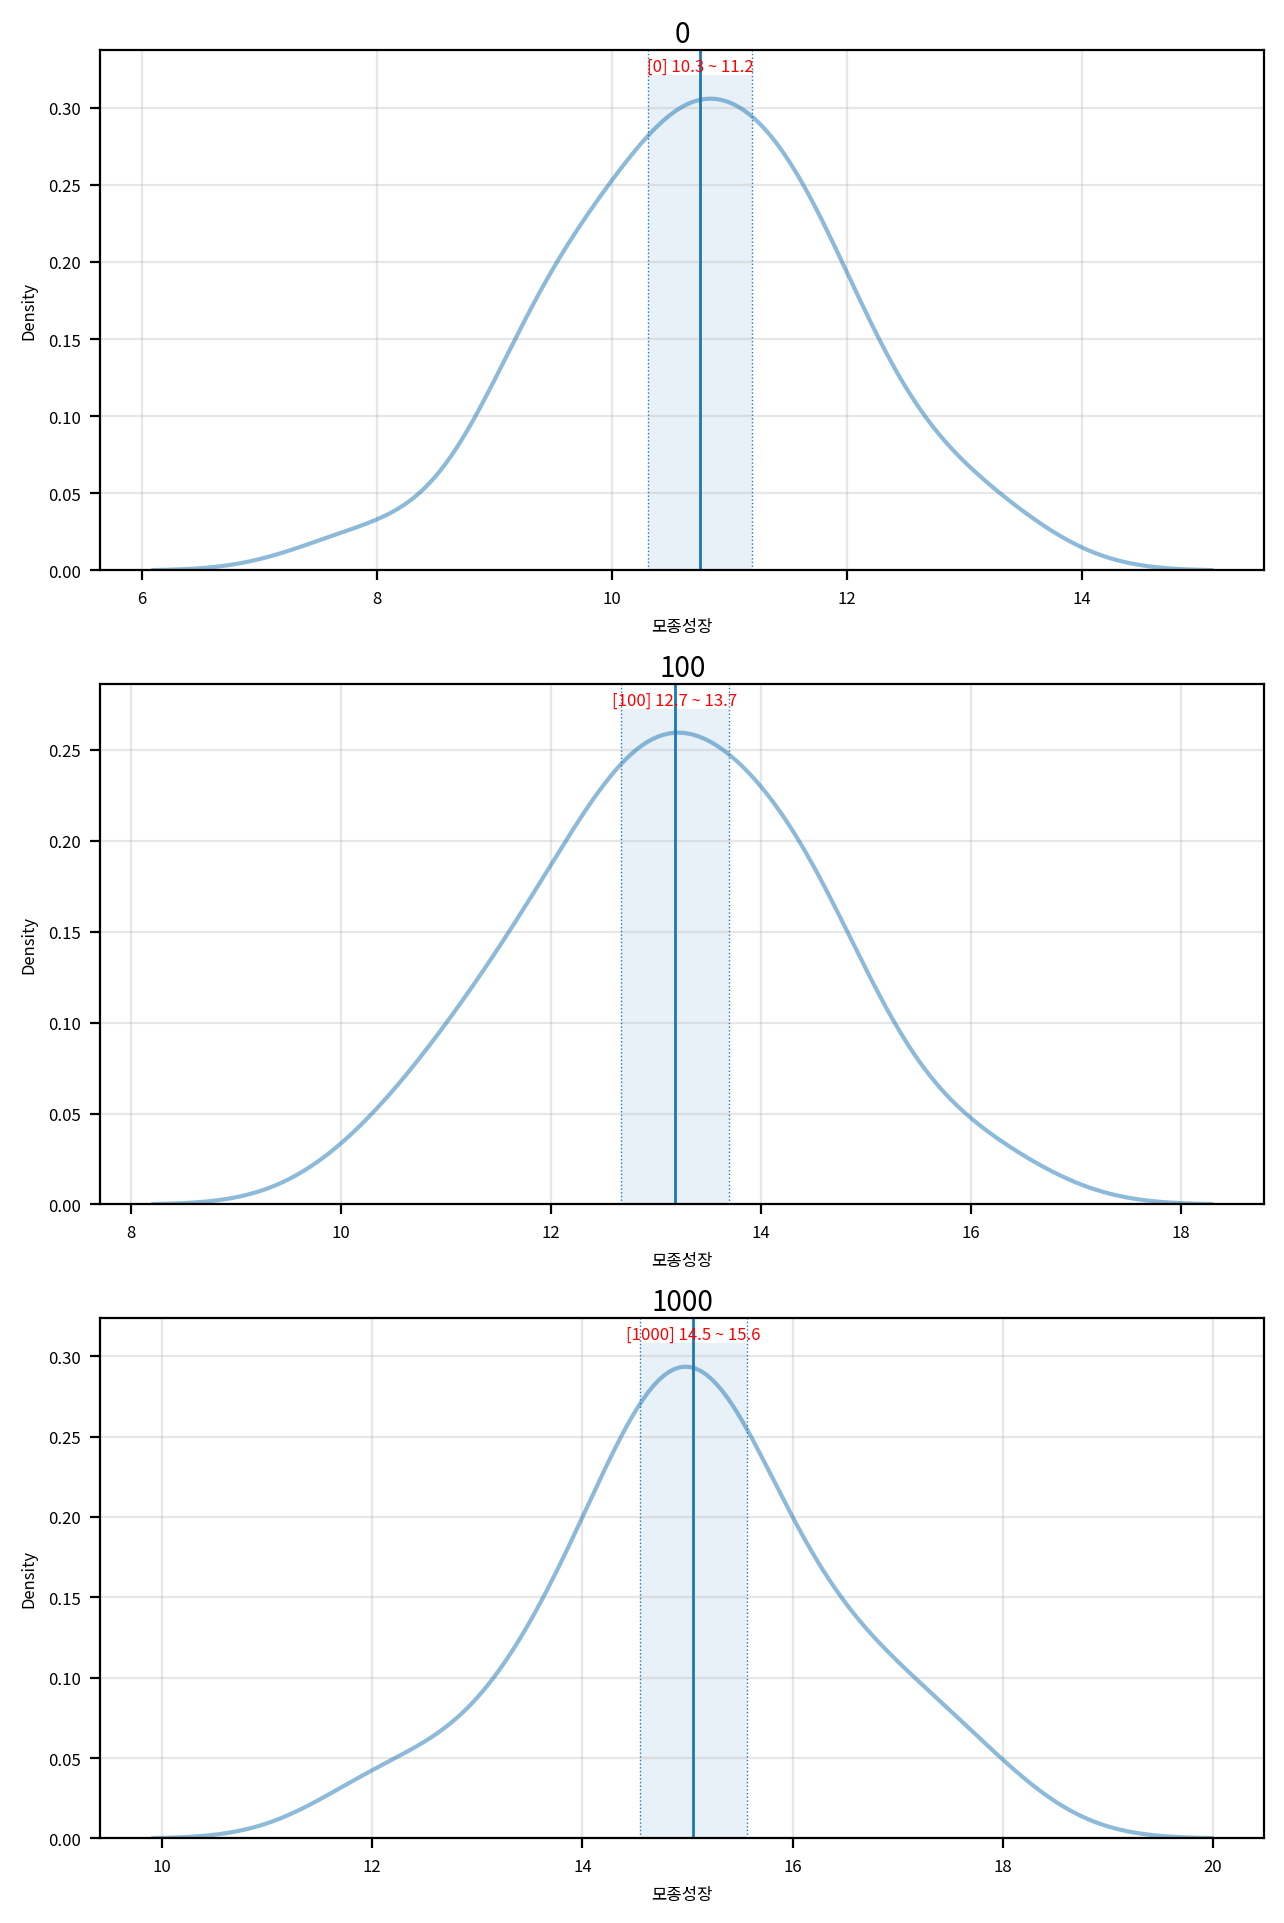

In [8]:
# 확인할 데이터 필드
field = '모종성장'

# 집단을 구분하는 필드 (hue)
hue_field = '효소함량'

# 종류 구하기
hue_values = origin[hue_field].unique()
hue_count = len(hue_values)

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 640 * 3  # 그래프 세로 크기
rows = 3
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 여러 그래프일 때 ax를 리스트로 처리
if rows * cols == 1:
    ax = [ax]

for i, v in enumerate(hue_values):
    temp = origin[origin[hue_field] == v]

    # KDE Plot 그리기
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)

    # 신뢰구간
    max_val = temp[field].max()
    clevel = 0.95  # 신뢰수준
    dof = len(temp[field]) - 1  # 자유도

    sp_mean = temp[field].mean()  # 표본평균
    sp_std = temp[field].std(ddof=1)  # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp[field]))  # 표본표준오차

    # t분포 신뢰구간 계산
    cmin, cmax = t.interval(
        clevel,
        dof,
        loc=sp_mean,
        scale=sp_std_error
    )

    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)

    # 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='-', linewidth=1)

    # 텍스트 그리기
    ax[i].text(
        x=(cmax - cmin) / 2 + cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (v, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"}
    )

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


📝 3. 가정 확인

In [9]:
# 효소함량별 그룹 생성
groups = [(name, grp['모종성장']) for name, grp in origin.groupby('효소함량')]

report = []
normal_dist = True

# 정규성 검정 (Normality Test)
for name, series in groups:
    stat, p = normaltest(series)
    ok = p > 0.05

    report.append({
        "field": name,
        "statistic": stat,
        "p-value": p,
        "result": ok
    })

    normal_dist = normal_dist and ok

# 등분산성 검정 선택
if normal_dist:
    test_name = "Bartlett"
    stat, p = bartlett(*[s.values for _, s in groups])
else:
    test_name = "Levene"
    stat, p = levene(*[s.values for _, s in groups], center='median')

equal_var = p > 0.05

# 등분산 결과 추가
report.append({
    "field": test_name,
    "statistic": stat,
    "p-value": p,
    "result": equal_var
})

# DataFrame 변환
report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
0,0.237689,0.887946,True
100,0.000368,0.999816,True
1000,0.234748,0.889253,True
Bartlett,0.776052,0.678395,True


📝 4. 사후분석

In [10]:
if equal_var:
    print("=== Tukey HSD ===")
    hoc_df = pairwise_tukey(data=origin, dv='모종성장',between='효소함량')
else:
    print("=== Games-Howell ===")
    hoc_df = pairwise_gameshowell(origin,dv='모종성장',between='효소함량')

hoc_df


=== Tukey HSD ===


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,0,100,10.753333,13.180000,-2.426667,0.338824,-7.162024,7.228520e-10,-1.867526
1,0,1000,10.753333,15.056667,-4.303333,0.338824,-12.700788,2.220446e-15,-3.315507
2,100,1000,13.180000,15.056667,-1.876667,0.338824,-5.538763,9.517362e-07,-1.350914


📝 5. 인사이트<br>
1) 분산분석(One-way ANOVA) 결과<br>
효소함량 요인의 주효과가 통계적으로 유의함<br>
F(2, 87) = 81.09<br>
p < .001<br>
➡ 해석: 효소함량 수준(0, 100, 1000에 따라 가정) 간 반응값 평균에는 실질적이고 통계적으로 유의한 차이가 존재한다.<br>
2) 사후검정(Tukey HSD) 결과<br>
모든 집단 쌍 비교에서 유의한 평균 차이가 나타났다.<br>
모든 p-tukey 값이 < .001 → 세 집단 모두 서로 차이를 보임<br>
➡ 해석: 효소함량이 증가할수록 평균 반응값도 뚜렷하게 증가하며, 0 < 100 < 1000 순으로 효과가 크다.<br>
3) 종합 결론<br>
효소함량은 반응값에 강력한 영향을 미치는 요인이다.<br>
분산분석과 사후검정 모두에서 각 효소 수준 간 차이가 명확히 구분된다.<br>

📘 문제 3<br>
edu 데이터 셋은 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말<br>
시험 성적을 조사한 자료이다.<br>
이 자료를 이용하여 두 가지 교육방법에 대한 국어와 영어의 효과가 서로 다르다고 할 수 있는지검정하라. (분석 목적에 맞는 데이터 재배치 과정이 필요합니다.)<br>

In [11]:
origin = load_data('edu')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/edu.xlsx
[desc] 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (22, 3)
열 개수: 3
행 개수: 22

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   교육방법    22 non-null     int64
 1   국어      22 non-null     int64
 2   영어      22 non-null     int64
dtypes: int64(3)
memory usage: 660.0 bytes
None


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


📝 2. 데이터 재배치

In [12]:
df = melt(origin, id_vars='교육방법',
    value_vars=['국어', '영어'],
    var_name='과목', value_name='점수')
df.head()

,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


📝 3. 데이터 분포 확인

1) 교육방법에 따른 과목별 점수

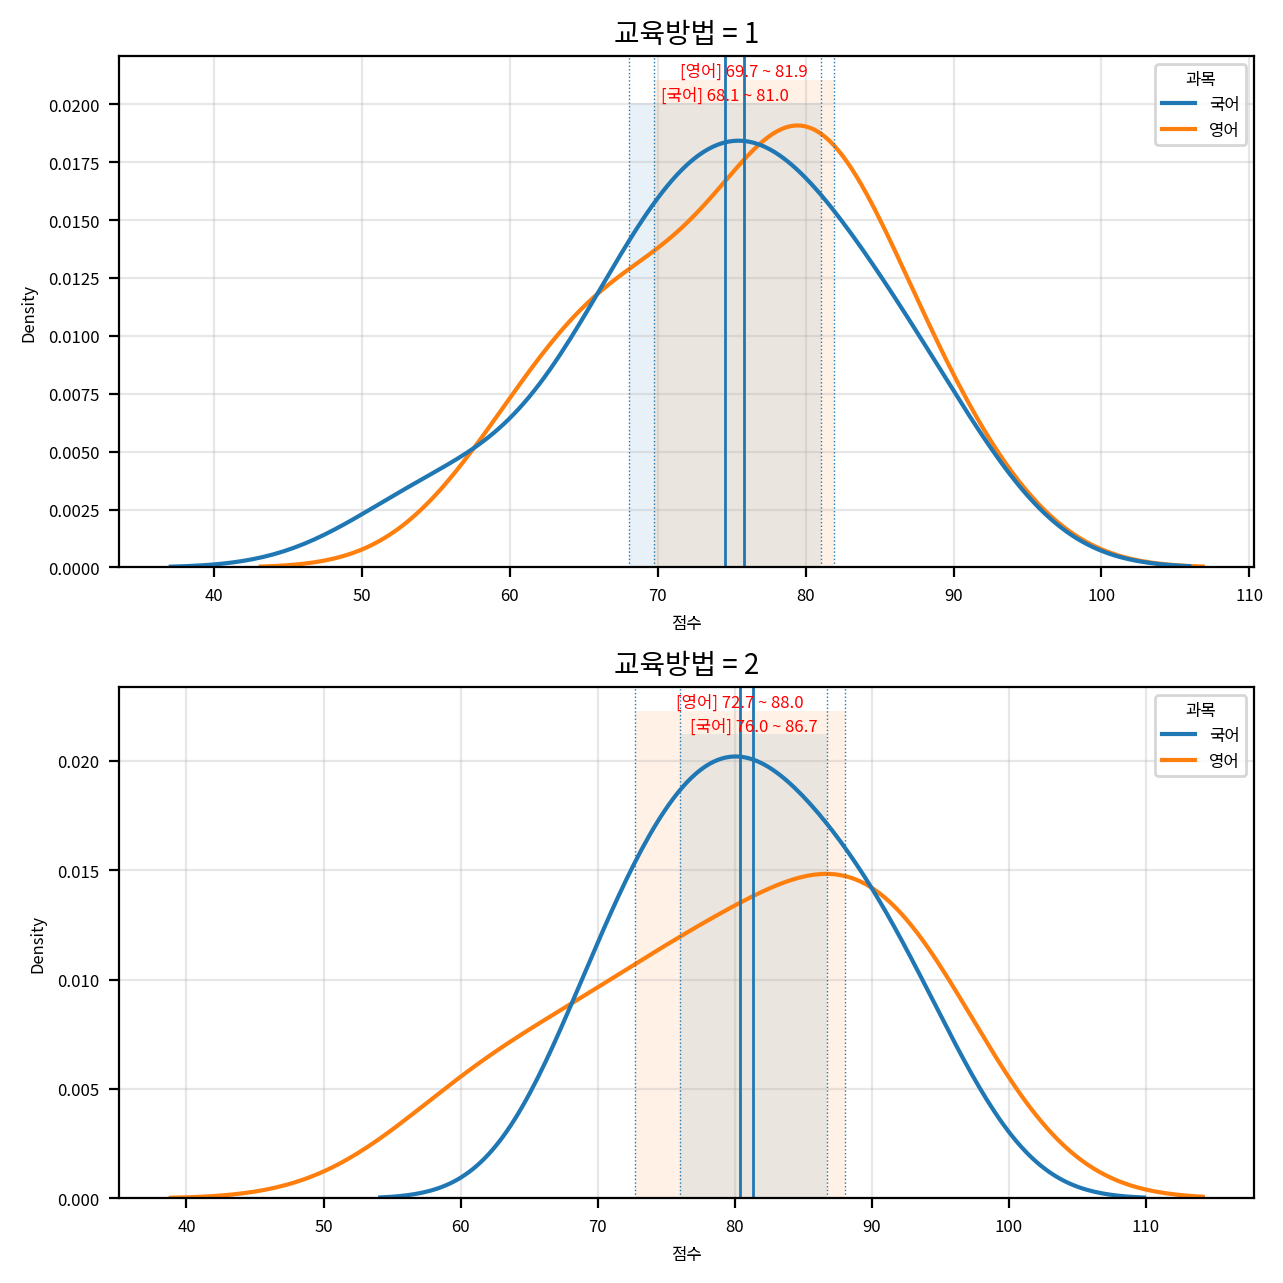

In [13]:
field = '점수'
group_field = '교육방법'
hue_field = '과목'

# 시각화 할 필드만 원본 데이터에서 추출
data = df[[field, group_field, hue_field]]

group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count
cols = 1

width_px = 1280 * cols
height_px = 640 * rows
figsize = (width_px / my_dpi, height_px / my_dpi)

fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# ax가 단일 객체이면 리스트로 변환
if rows == 1:
    ax = [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]

    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        if len(temp_sub) < 2:
            continue  # 신뢰구간 계산 불가

        # 신뢰구간 계산
        max_val = temp_sub[field].max()
        clevel = 0.95
        dof = len(temp_sub[field]) - 1

        sp_mean = temp_sub[field].mean()
        sp_std = temp_sub[field].std(ddof=1)
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))

        cmin, cmax = t.interval(
            clevel, dof,
            loc=sp_mean,
            scale=sp_std_error
        )

        # 신뢰구간 표시선
        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)

        # 평균 표시
        ymin, ymax = ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='-', linewidth=1)

        # 텍스트 표시
        ax[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s=f"[{h}] {cmin:.1f} ~ {cmax:.1f}",
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"}
        )

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()



2) 과목에 따른 교육방법별 점수

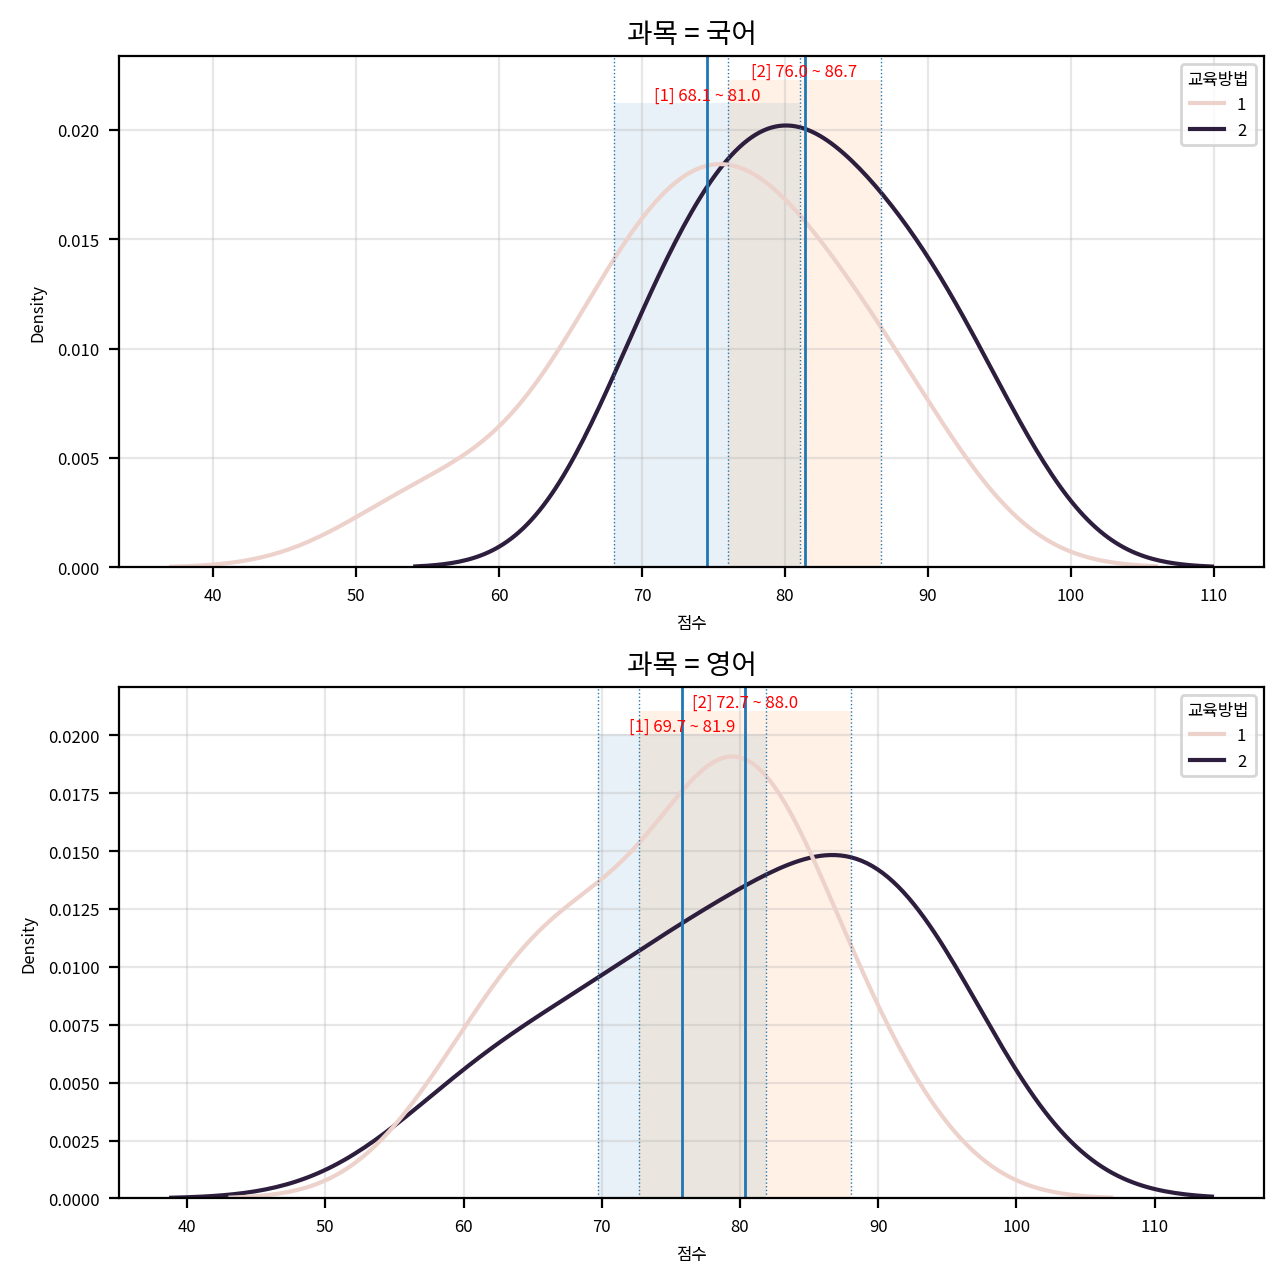

In [14]:
field = '점수'
group_field = '과목'
hue_field = '교육방법'

# 시각화 할 필드만 원본 데이터에서 추출
data = df[[field, group_field, hue_field]]

group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count
cols = 1

width_px = 1280 * cols
height_px = 640 * rows
figsize = (width_px / my_dpi, height_px / my_dpi)

fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# ax가 단일 객체이면 리스트로 변환
if rows == 1:
    ax = [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):

    temp = data[data[group_field] == v]

    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        if len(temp_sub) < 2:
            continue  # 신뢰구간 계산 불가 시 skip

        # 신뢰구간 계산
        clevel = 0.95
        dof = len(temp_sub[field]) - 1

        sp_mean = temp_sub[field].mean()
        sp_std = temp_sub[field].std(ddof=1)
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))

        cmin, cmax = t.interval(
            clevel,
            dof,
            loc=sp_mean,
            scale=sp_std_error
        )

        # 신뢰구간 표시
        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)

        # 평균 표시
        ymin, ymax = ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='-', linewidth=1)

        # 텍스트 표시
        ax[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s=f"[{h}] {cmin:.1f} ~ {cmax:.1f}",
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"}
        )

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


📝 4. 가정 확인

In [15]:
data = df.copy()

xname = ['교육방법', '과목']
yname = '점수'

u1 = data[xname[0]].unique()
u2 = data[xname[1]].unique()

equal_var_fields = []
normal_dist = True
report = []

# 그룹별 정규성 검정
for i in u1:
    for j in u2:
        filtered_data = data[
            (data[xname[0]] == i) &
            (data[xname[1]] == j)
        ][yname]

        equal_var_fields.append(filtered_data)

        s, p = normaltest(filtered_data)
        normalize = p > 0.05

        report.append({
            "field": f"{i}, {j}",
            "statistic": s,
            "p-value": p,
            "result": normalize
        })

        normal_dist = normal_dist and normalize

# 등분산성 검정 선택
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)

equal_var = p > 0.05

report.append({
    "field": n,
    "statistic": s,
    "p-value": p,
    "result": equal_var
})

# DataFrame 생성
report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
"1, 국어",0.911351,0.634020,True
"1, 영어",0.389198,0.823165,True
"2, 국어",0.299661,0.860854,True
"2, 영어",1.094669,0.578490,True
Bartlett,2.871293,0.411898,True


📝 5. 분산분석

In [16]:
xname = ['교육방법', '과목']
yname = '점수'

data = df[xname + [yname]]

# ANOVA 또는 Welch-ANOVA 선택
if equal_var:
    pg_anova = anova(data=data, dv=yname, between=xname)
else:
    pg_anova = welch_anova(data=data, dv=yname, between=xname)

display(pg_anova)

# 유의성 판정
for idx in pg_anova.index:
    row = pg_anova.loc[idx]

    source = row['Source']
    p_val = row['p-unc']

    if p_val <= 0.05:
        print(f"→ {source} 효과는 유의함. (대립가설 채택: p ≤ 0.05)")
    else:
        print(f"→ {source} 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)")


,Source,SS,DF,MS,F,p-unc,np2
0,교육방법,355.113636,1,355.113636,3.845870,0.056857,0.087713
1,과목,0.204545,1,0.204545,0.002215,0.962695,0.000055
2,교육방법 * 과목,14.204545,1,14.204545,0.153835,0.696979,0.003831
3,Residual,3693.454545,40,92.336364,NaN,NaN,NaN


→ 교육방법 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
→ 과목 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
→ 교육방법 * 과목 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
→ Residual 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
